<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/M%C3%B4_h%C3%ACnh_MLP_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/insurance.csv")

BƯỚC 1 — IMPORT THƯ VIỆN

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim

In [43]:
pd_train.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
#Encode biến phân loại:
pd_train = pd.get_dummies(pd_train, drop_first=True)
print("Dữ liệu sau khi mã hóa thành công:")
display(pd_train.head())

Dữ liệu sau khi mã hóa thành công:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Xóa giá trị ngoại lai

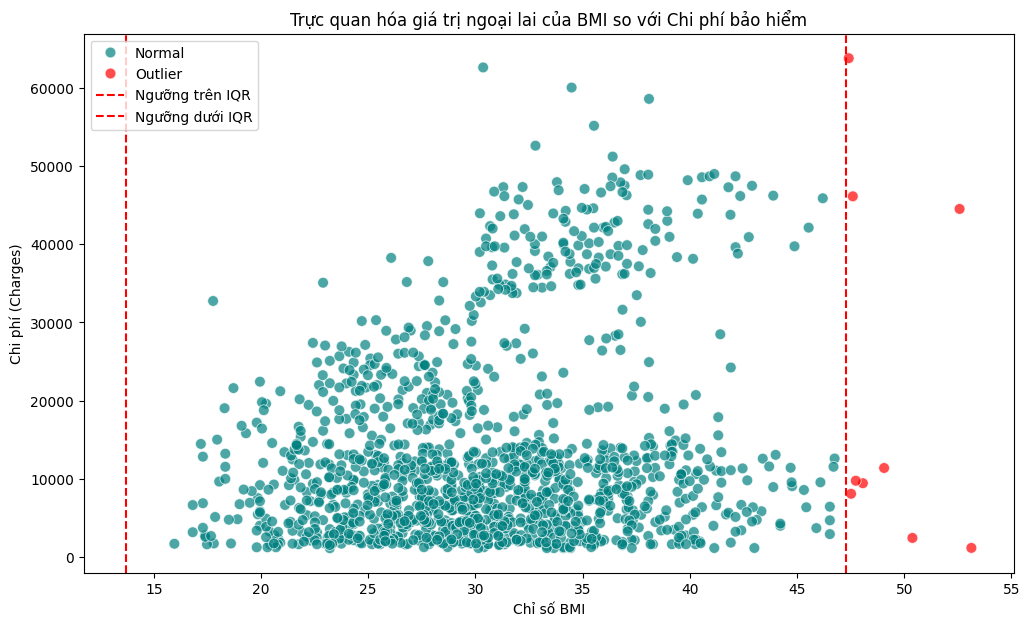

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán ngưỡng IQR cho cột BMI
Q1 = pd_train['bmi'].quantile(0.25)
Q3 = pd_train['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Tạo cột phân loại Outlier
# Hàm này sẽ trả về 'Outlier' nếu giá trị nằm ngoài ngưỡng, ngược lại là 'Normal'
pd_train['is_outlier'] = pd_train['bmi'].apply(
    lambda x: 'Outlier' if (x < lower_bound or x > upper_bound) else 'Normal'
)

# 3. Vẽ biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(12, 7))

# Dùng tham số 'hue' để phân biệt màu sắc dựa trên cột 'is_outlier'
# 'palette' giúp bạn chọn màu cụ thể (ví dụ: đỏ cho Outlier, xanh cho Normal)
sns.scatterplot(
    data=pd_train,
    x='bmi',
    y='charges',
    hue='is_outlier',
    palette={'Normal': 'teal', 'Outlier': 'red'},
    alpha=0.7,
    s=60
)

# Vẽ thêm đường giới hạn để dễ quan sát
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Ngưỡng trên IQR')
plt.axvline(x=lower_bound, color='red', linestyle='--', label='Ngưỡng dưới IQR')

plt.title('Trực quan hóa giá trị ngoại lai của BMI so với Chi phí bảo hiểm')
plt.xlabel('Chỉ số BMI')
plt.ylabel('Chi phí (Charges)')
plt.legend()
plt.show()

# Sau khi xem xong, bạn nhớ xóa cột tạm này để tránh ảnh hưởng bước huấn luyện
#pd_train.drop(columns=['is_outlier'], inplace=True)

In [46]:
pd_train.drop(columns=['is_outlier'], inplace=True)

In [47]:
#Xử lý các giá trị ngoại lai cho cột BMI
import numpy as np

# Giả sử đây là cột BMI trong dữ liệu của bạn
bmi_data = pd_train['bmi']

# 1. Tính Q1, Q3
Q1 = bmi_data.quantile(0.25)
Q3 = bmi_data.quantile(0.75)

# 2. Tính IQR
IQR = Q3 - Q1

# 3. Xác định ngưỡng
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# 4. Lọc dữ liệu
outliers = bmi_data[(bmi_data < lower_limit) | (bmi_data > upper_limit)]
df_cleaned = pd_train[(pd_train['bmi'] >= lower_limit) & (pd_train['bmi'] <= upper_limit)]

print(f"Ngưỡng an toàn của BMI: từ {lower_limit:.2f} đến {upper_limit:.2f}")
print(f"Số lượng Outliers bị loại bỏ: {len(outliers)}")

Ngưỡng an toàn của BMI: từ 13.70 đến 47.29
Số lượng Outliers bị loại bỏ: 9


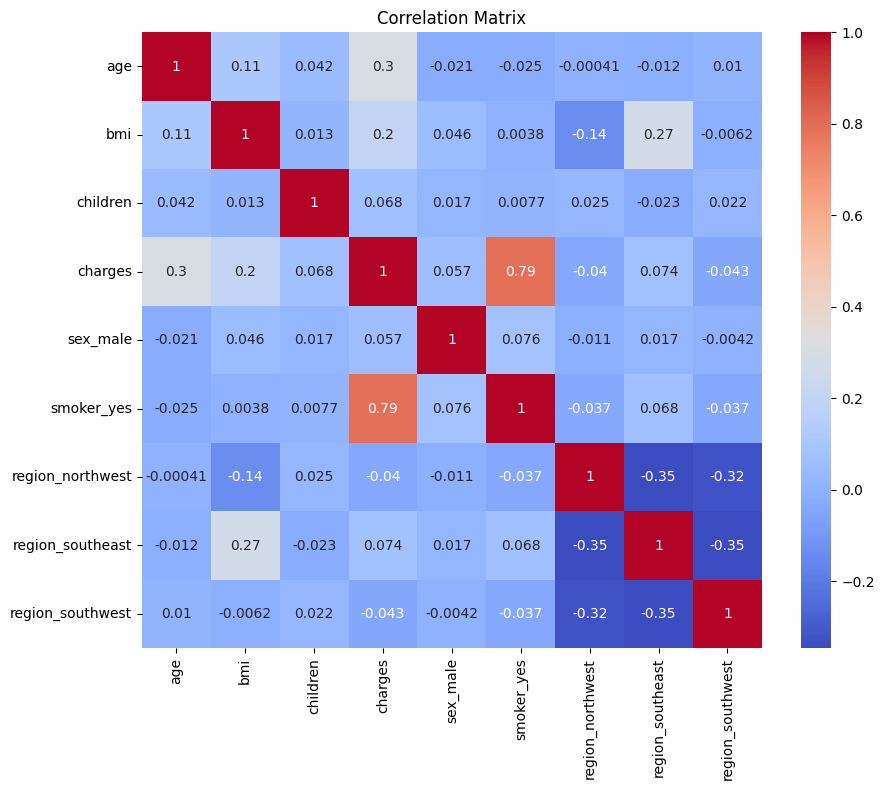

In [48]:
#Ma trận tương quan
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd_train.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Tách X và y

In [49]:
X = pd_train.drop("charges", axis=1)
y = pd_train["charges"]

In [50]:
# Chia train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

In [53]:
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [54]:
#Chuyển sang Tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

Model KHÔNG Dropout

In [55]:
class MLP_NoDropout(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

Model CÓ Dropout

In [56]:
class MLP_Dropout(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            #nn.Dropout(0.1),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

Hàm train chung

In [57]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=200):

    criterion = nn.MSELoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()

        y_pred = model(X_train)

        loss = criterion(y_pred, y_train)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        # ===== VALIDATION =====
        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = criterion(val_pred, y_val)

        val_losses.append(val_loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {loss.item():.4f} | "
                  f"Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses

Train model KHÔNG Dropout

In [58]:
# Lấy số lượng feature đầu vào
input_size = X_train.shape[1]

# Khởi tạo model đúng cách
model_no_dropout = MLP_NoDropout(input_size)

# Train model
train_loss_no, val_loss_no = train_model(
    model_no_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 20/200 | Train Loss: 0.0213 | Val Loss: 0.0189
Epoch 40/200 | Train Loss: 0.0113 | Val Loss: 0.0082
Epoch 60/200 | Train Loss: 0.0100 | Val Loss: 0.0077
Epoch 80/200 | Train Loss: 0.0092 | Val Loss: 0.0071
Epoch 100/200 | Train Loss: 0.0084 | Val Loss: 0.0068
Epoch 120/200 | Train Loss: 0.0076 | Val Loss: 0.0062
Epoch 140/200 | Train Loss: 0.0068 | Val Loss: 0.0057
Epoch 160/200 | Train Loss: 0.0063 | Val Loss: 0.0055
Epoch 180/200 | Train Loss: 0.0060 | Val Loss: 0.0054
Epoch 200/200 | Train Loss: 0.0058 | Val Loss: 0.0054


Train model có Dropout

In [59]:
# Lấy số lượng feature đầu vào
input_size = X_train.shape[1]

# Khởi tạo model có Dropout
model_dropout = MLP_Dropout(input_size)

# Train model
train_loss_drop, val_loss_drop = train_model(
    model_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 20/200 | Train Loss: 0.0376 | Val Loss: 0.0355
Epoch 40/200 | Train Loss: 0.0188 | Val Loss: 0.0151
Epoch 60/200 | Train Loss: 0.0137 | Val Loss: 0.0084
Epoch 80/200 | Train Loss: 0.0122 | Val Loss: 0.0077
Epoch 100/200 | Train Loss: 0.0109 | Val Loss: 0.0071
Epoch 120/200 | Train Loss: 0.0097 | Val Loss: 0.0067
Epoch 140/200 | Train Loss: 0.0104 | Val Loss: 0.0064
Epoch 160/200 | Train Loss: 0.0092 | Val Loss: 0.0061
Epoch 180/200 | Train Loss: 0.0087 | Val Loss: 0.0059
Epoch 200/200 | Train Loss: 0.0084 | Val Loss: 0.0058


Vẽ Loss Curve

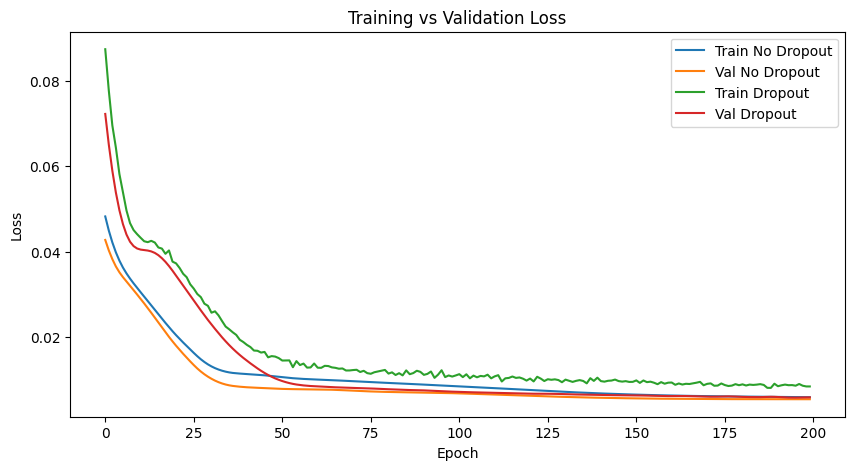

In [60]:
plt.figure(figsize=(10,5))

# No Dropout
plt.plot(train_loss_no, label='Train No Dropout')
plt.plot(val_loss_no, label='Val No Dropout')

# Dropout
plt.plot(train_loss_drop, label='Train Dropout')
plt.plot(val_loss_drop, label='Val Dropout')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

Hàm đánh giá model

In [61]:
def evaluate_model(model, X_test, y_test):

    model.eval()

    with torch.no_grad():

        predictions = model(X_test)

    predictions = predictions.numpy()
    y_true = y_test.numpy()

    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(mean_squared_error(y_true, predictions))

    r2 = r2_score(y_true, predictions)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

    return predictions

Đánh giá model KHÔNG Dropout

In [62]:
print("===== NO DROPOUT =====")

pred_no = evaluate_model(
    model_no_dropout,
    X_test,
    y_test
)

===== NO DROPOUT =====
MAE  : 0.04
RMSE : 0.07
R2   : 0.8605


Đánh giá model CÓ Dropout

In [63]:
print("===== DROPOUT =====")

pred_drop = evaluate_model(
    model_dropout,
    X_test,
    y_test
)

===== DROPOUT =====
MAE  : 0.05
RMSE : 0.08
R2   : 0.8389


CÁCH 2

In [ ]:
class MLP_NoDropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
class MLP_Dropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=300):

    criterion = nn.MSELoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()

        y_pred = model(X_train)

        loss = criterion(y_pred, y_train)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        # ===== VALIDATION =====
        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = criterion(val_pred, y_val)

        val_losses.append(val_loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {loss.item():.4f} | "
                  f"Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses

In [ ]:
# Lấy số lượng feature đầu vào
input_size = X_train.shape[1]

# Khởi tạo model đúng cách
model_no_dropout = MLP_NoDropout(input_size)

# Train model
train_loss_no, val_loss_no = train_model(
    model_no_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 20/300 | Train Loss: 0.0135 | Val Loss: 0.0111
Epoch 40/300 | Train Loss: 0.0097 | Val Loss: 0.0080
Epoch 60/300 | Train Loss: 0.0082 | Val Loss: 0.0070
Epoch 80/300 | Train Loss: 0.0067 | Val Loss: 0.0059
Epoch 100/300 | Train Loss: 0.0058 | Val Loss: 0.0053
Epoch 120/300 | Train Loss: 0.0054 | Val Loss: 0.0053
Epoch 140/300 | Train Loss: 0.0051 | Val Loss: 0.0054
Epoch 160/300 | Train Loss: 0.0049 | Val Loss: 0.0054
Epoch 180/300 | Train Loss: 0.0047 | Val Loss: 0.0055
Epoch 200/300 | Train Loss: 0.0046 | Val Loss: 0.0056
Epoch 220/300 | Train Loss: 0.0044 | Val Loss: 0.0057
Epoch 240/300 | Train Loss: 0.0042 | Val Loss: 0.0057
Epoch 260/300 | Train Loss: 0.0041 | Val Loss: 0.0058
Epoch 280/300 | Train Loss: 0.0039 | Val Loss: 0.0059
Epoch 300/300 | Train Loss: 0.0038 | Val Loss: 0.0060


In [ ]:
# Lấy số lượng feature đầu vào
input_size = X_train.shape[1]

# Khởi tạo model có Dropout
model_dropout = MLP_Dropout(input_size)

# Train model
train_loss_drop, val_loss_drop = train_model(
    model_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 20/300 | Train Loss: 0.0128 | Val Loss: 0.0084
Epoch 40/300 | Train Loss: 0.0107 | Val Loss: 0.0072
Epoch 60/300 | Train Loss: 0.0088 | Val Loss: 0.0061
Epoch 80/300 | Train Loss: 0.0082 | Val Loss: 0.0056
Epoch 100/300 | Train Loss: 0.0085 | Val Loss: 0.0055
Epoch 120/300 | Train Loss: 0.0077 | Val Loss: 0.0056
Epoch 140/300 | Train Loss: 0.0075 | Val Loss: 0.0056
Epoch 160/300 | Train Loss: 0.0069 | Val Loss: 0.0054
Epoch 180/300 | Train Loss: 0.0069 | Val Loss: 0.0056
Epoch 200/300 | Train Loss: 0.0066 | Val Loss: 0.0056
Epoch 220/300 | Train Loss: 0.0068 | Val Loss: 0.0055
Epoch 240/300 | Train Loss: 0.0066 | Val Loss: 0.0056
Epoch 260/300 | Train Loss: 0.0063 | Val Loss: 0.0057
Epoch 280/300 | Train Loss: 0.0062 | Val Loss: 0.0055
Epoch 300/300 | Train Loss: 0.0061 | Val Loss: 0.0057


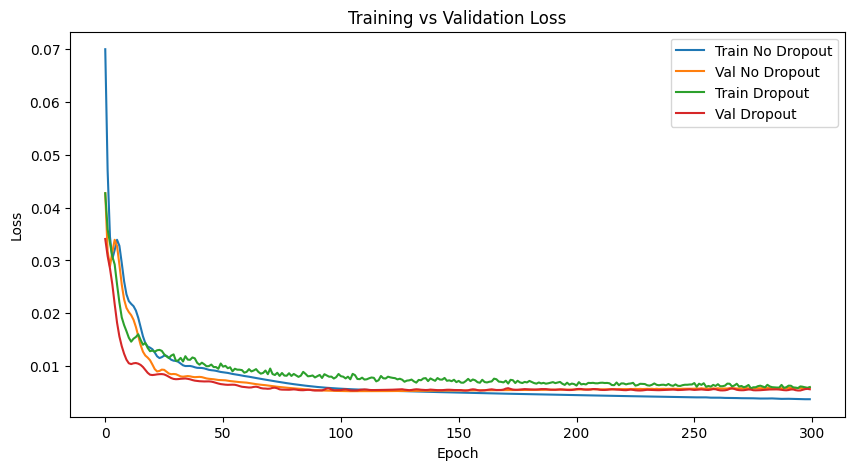

In [ ]:
plt.figure(figsize=(10,5))

# No Dropout
plt.plot(train_loss_no, label='Train No Dropout')
plt.plot(val_loss_no, label='Val No Dropout')

# Dropout
plt.plot(train_loss_drop, label='Train Dropout')
plt.plot(val_loss_drop, label='Val Dropout')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
print("===== NO DROPOUT =====")

pred_no = evaluate_model(
    model_no_dropout,
    X_test,
    y_test
)

===== NO DROPOUT =====
MAE  : 0.05
RMSE : 0.08
R2   : 0.8419


In [ ]:
print("===== DROPOUT =====")

pred_drop = evaluate_model(
    model_dropout,
    X_test,
    y_test
)

===== DROPOUT =====
MAE  : 0.04
RMSE : 0.08
R2   : 0.8534
